# Deep Learning Module End
## By Gladwin Thomas
## DS09

## 1. Loading and Preprocessing 
### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

I0000 00:00:1784481683.532525  184460 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load Dataset

In [2]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


### Check Missing Values

In [5]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

#### Explanation

The Diabetes dataset from sklearn contains 442 samples and 10 numerical features. There are no missing values, so no imputation is required.

### Feature Normalization

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 2. Exploratory Data Analysis
### Distribution of Target

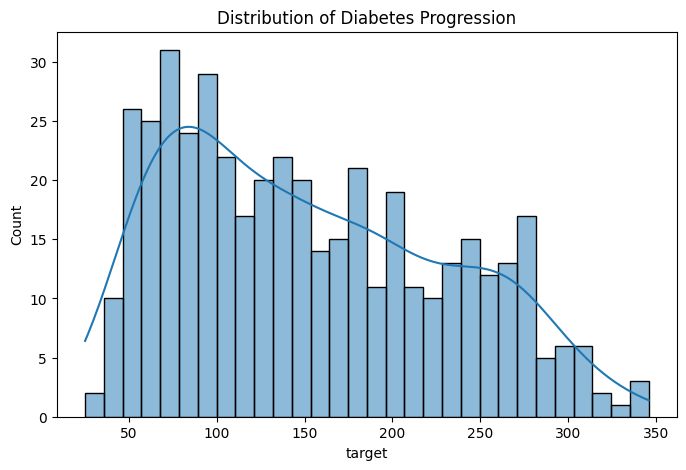

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

### Correlation Heatmap

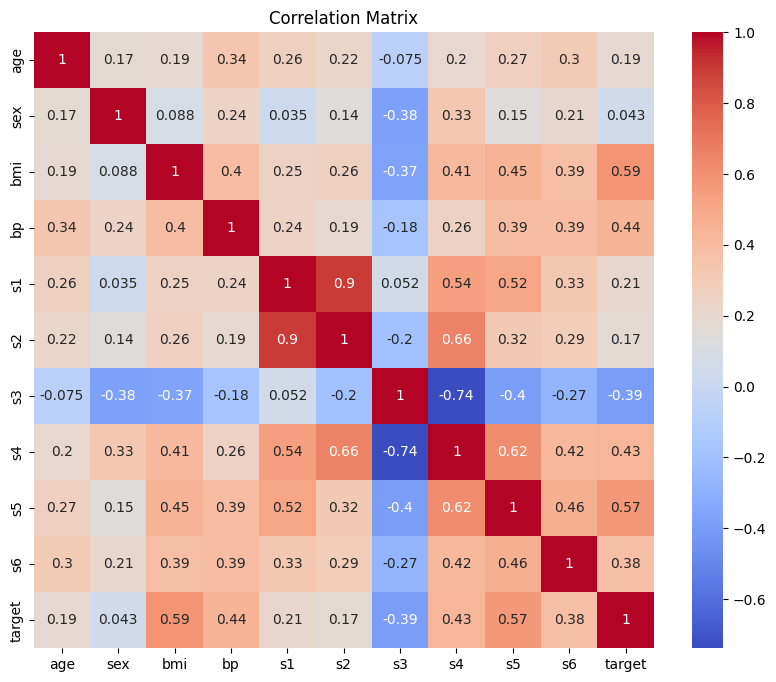

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Pairplot

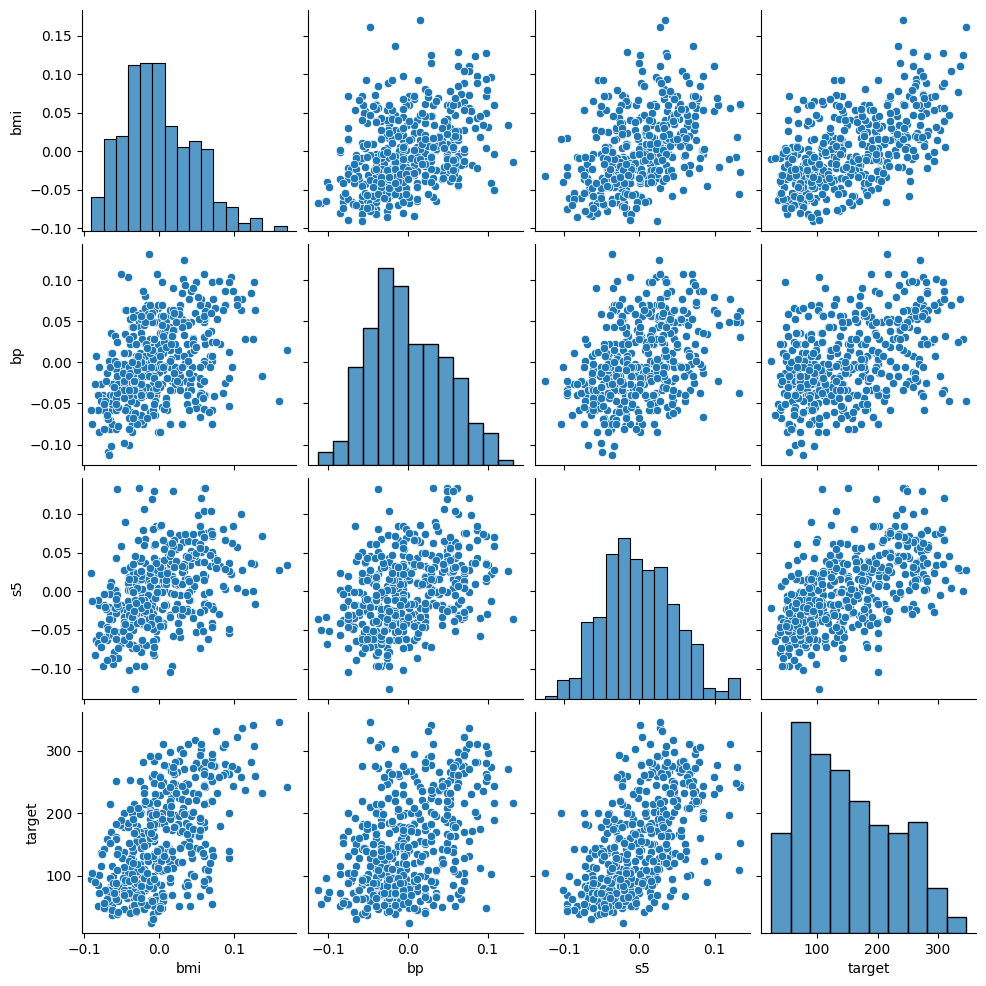

In [9]:
sns.pairplot(df[['bmi','bp','s5','target']])
plt.show()

### Feature Relationships

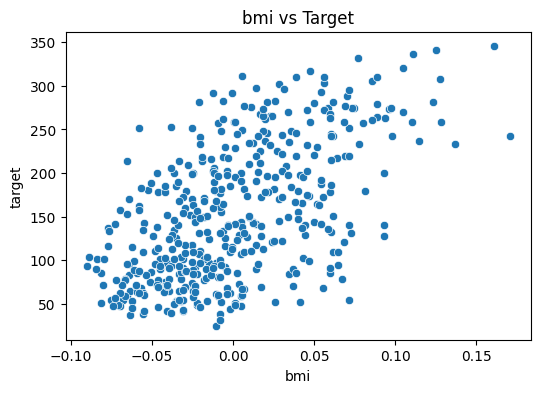

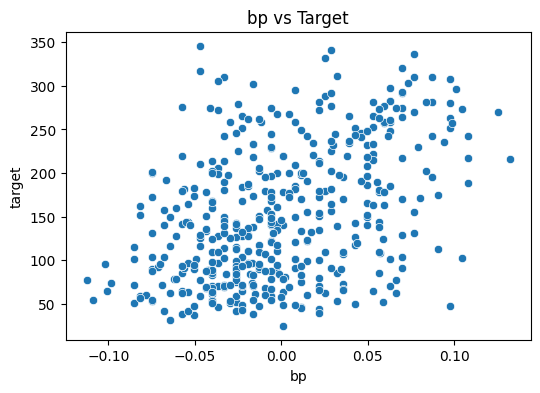

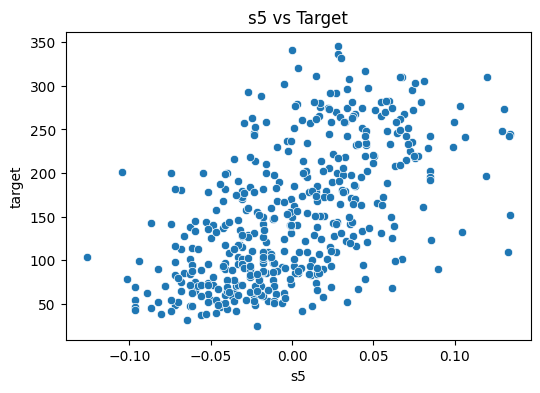

In [10]:
features = ['bmi','bp','s5']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df,x=feature,y='target')
    plt.title(f"{feature} vs Target")
    plt.show()

### EDA Observations

- The dataset contains 10 numerical features.
- The target variable follows a moderately normal distribution.
- BMI shows the strongest positive correlation with diabetes progression.
- Blood pressure (bp) also has a positive relationship with the target.
- Feature s5 exhibits one of the highest correlations with disease progression.
- No significant outliers are observed after normalization.

## 3. Build ANN Model
### Design a simple ANN architecture with at least one hidden layer. Use an appropriate activation functions.

In [11]:
model = Sequential([
    Input(shape=(10,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

I0000 00:00:1784481690.644120  184460 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3284 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training the ANN Model
### Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

### Compile Model and setting appropriate optimizers and loss functions

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
)

### Setting Early Stopping

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

### Training the Model

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


I0000 00:00:1784481693.303444  184515 service.cc:153] XLA service 0x71a2e4032110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784481693.303466  184515 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1050, Compute Capability 6.1 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1784481693.336278  184515 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784481693.611145  184515 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1784481693.618804  184515 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1256__.9


18/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27851.4035 - mae: 149.6126

I0000 00:00:1784481694.915517  184515 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29156.5512 - mae: 152.6786

I0000 00:00:1784481695.419205  184515 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1256__.9


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 31098.0781 - mae: 157.4160 - val_loss: 21829.3223 - val_mae: 131.7726
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29966.7734 - mae: 154.0845 - val_loss: 20648.6309 - val_mae: 127.6111
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 27486.7559 - mae: 146.8244 - val_loss: 18291.0020 - val_mae: 119.0555
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23001.2969 - mae: 132.3886 - val_loss: 14523.5068 - val_mae: 104.1220
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16621.7441 - mae: 109.4757 - val_loss: 10094.8838 - val_mae: 82.5167
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10555.8955 - mae: 82.5148 - val_loss: 6504.4351 - val_mae: 60.1158
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6802.4316 - mae: 64.1063 - val_loss: 4717.0801 - val_mae: 49.6820
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5377.9004 - mae: 56.9776 - val_loss: 3982.4578 - v

Epoch 52/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2672.0227 - mae: 41.3647 - val_loss: 2925.6047 - val_mae: 42.9161
Epoch 53/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2654.5234 - mae: 41.1983 - val_loss: 2919.1421 - val_mae: 42.8070
Epoch 54/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2655.8396 - mae: 41.3377 - val_loss: 2890.2214 - val_mae: 42.6833
Epoch 55/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2643.5637 - mae: 41.2005 - val_loss: 2903.3984 - val_mae: 42.7454
Epoch 56/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2636.1831 - mae: 41.1435 - val_loss: 2897.3403 - val_mae: 42.7119
Epoch 57/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2638.1169 - mae: 41.0956 - val_loss: 2931.1975 - val_mae: 43.0081
Epoch 58/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2614.5728 - mae: 41.0006 - val_loss: 2929.3242 - val_mae: 42.9882
Epoch 59/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2619.0039 - mae: 40.9945 - val_loss: 2919.5190 - va

## 5. Evaluating the model
### Learning Curve

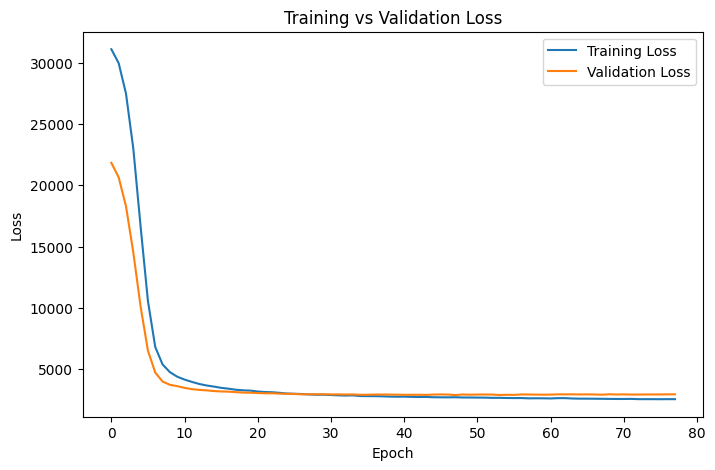

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

### Making Predictions on the test data

In [17]:
predictions = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step


### Model Evaluation

In [18]:
mse = mean_squared_error(y_test,predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictions)

print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Squared Error : 2850.427137182803
Root Mean Squared Error : 53.38939161652625
R2 Score : 0.46199594264530497


## 6. Improving the Model



### Function to Train and Evaluate


In [19]:
def evaluate_model(model):

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=300,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    predictions = model.predict(X_test, verbose=0)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return mse, rmse, r2

### Experiment with different architectures, activation functions, or hyperparameters to improve the model performance.

### Model 1: BASELINE

In [20]:
model1 = Sequential([
    Input(shape=(10,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mse1, rmse1, r21 = evaluate_model(model1)

I0000 00:00:1784481734.335845  184512 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19447__.9
I0000 00:00:1784481736.048697  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19447__.9


### Model 2 : Deeper Architecture

In [21]:
model2 = Sequential([
    Input(shape=(10,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mse2, rmse2, r22 = evaluate_model(model2)

I0000 00:00:1784481758.830076  184513 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30344__.11
I0000 00:00:1784481761.119308  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30344__.11


### Model 3 : Tanh Activation

In [22]:
model3 = Sequential([
    Input(shape=(10,)),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(1)
])

model3.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mse3, rmse3, r23 = evaluate_model(model3)

I0000 00:00:1784481776.512415  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36850__.9
I0000 00:00:1784481777.571592  184512 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36850__.9


### Model 4 : L2 Regularization

In [23]:
model4 = Sequential([
    Input(shape=(10,)),
    Dense(64,
          activation='relu',
          kernel_regularizer=l2(0.0005)),
    Dense(32,
          activation='relu',
          kernel_regularizer=l2(0.0005)),
    Dense(1)
])

model4.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mse4, rmse4, r24 = evaluate_model(model4)

I0000 00:00:1784481858.715090  184513 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76180__.12
I0000 00:00:1784481860.262164  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76180__.12


### Model 5 : Lower Learning Rate

In [24]:
model5 = Sequential([
    Input(shape=(10,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model5.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

mse5, rmse5, r25 = evaluate_model(model5)

I0000 00:00:1784481889.669436  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_89736__.9
I0000 00:00:1784481890.377289  184511 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_89736__.9


### Model 6 : Smaller Batch Size

In [25]:
model6 = Sequential([
    Input(shape=(10,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model6.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

model6.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0
)

pred = model6.predict(X_test, verbose=0)

mse6 = mean_squared_error(y_test,pred)
rmse6 = np.sqrt(mse6)
r26 = r2_score(y_test,pred)

I0000 00:00:1784481973.079936  184512 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130697__.9
I0000 00:00:1784481973.842178  184515 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130697__.9


### Compare all models

In [26]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Baseline",
        "Deep ANN",
        "Tanh",
        "L2 Regularization",
        "Lower Learning Rate",
        "Batch Size = 8"
    ],

    "MSE":[
        mse1,
        mse2,
        mse3,
        mse4,
        mse5,
        mse6
    ],

    "RMSE":[
        rmse1,
        rmse2,
        rmse3,
        rmse4,
        rmse5,
        rmse6
    ],

    "R2 Score":[
        r21,
        r22,
        r23,
        r24,
        r25,
        r26
    ]

})

results.sort_values("R2 Score",ascending=False)

,Model,MSE,RMSE,R2 Score
5,Batch Size = 8,2818.645831,53.090920,0.467995
3,L2 Regularization,2895.009645,53.805294,0.453581
0,Baseline,2947.400892,54.289970,0.443693
1,Deep ANN,3032.052263,55.064074,0.427715
4,Lower Learning Rate,3496.919905,59.134761,0.339974
2,Tanh,4561.689023,67.540277,0.139004


## Conclusion

- It has been observed that l2 regularization with very small penalization helps us to improve our model from the baseline.
- It has been observed that reducing the learning rate very low increases the training time and decreases the performance.
- Reducing the batch size to 8 is found to perform well in terms of R2 score.
- ReLU is found to be the optimum activation function for this problem